# RL Learning - Cartpole Problem
- Learning continous Observation
- State Discretization
- Training/evaluation
- environment mechanics math

### Env Spec
- Observations : obs[4,] = [cart position, cart velocity, pole angle, pole angular velocity]
- Actions : action[1,] = [0(Left),1(Right)]
- Thresholds : pole angle -+12, cart position -+2.4, steps = 500

### Understanding Concepts

In [ ]:
# Testing variables
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1", render_mode="human")
obs, info = env.reset(seed=101)


done = False
step_num = 0

while not done:
    action = env.action_space.sample()
    next_obs,reward,terminated,truncated,info = env.step(action)

    print(f'Step {step_num}')
    print('obs:' ,obs)
    print('reward:' ,reward)
    print('action:' ,action)
    print('next obs:' ,next_obs)
    print('terminated:' ,terminated)
    print('truncated:' ,truncated)
    
    print('-*40')

    obs= next_obs
    step_num += 1

    done = terminated or truncated


env.close()


In [ ]:
# passing down policy manually

import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1", render_mode="human")
obs, info = env.reset(seed=101)


done = False
total = 0

while not done:
    pole_angle = obs[2]

    #action =1 if pole_angle > 0 else 0 
    action = 1 if (obs[2] + 0.2 * obs[3]) > 0 else 0

    obs, reward, terminated, truncated, info = env.step(action)
    total += reward
    done = terminated or truncated

print(f'Total Reward:' ,total)
env.close()


Total Reward: 500.0


- for memory we cant use Q- Table since, the state is continous , so we need to use state aggregation/binning.
- cart position → 6 bins
- cart velocity → 6 bins
- pole angle → 12 bins
- pole angular velocity → 12 bins

In [16]:
# Training Loop

import numpy as np

# Choose clipping ranges

env = gym.make("CartPole-v1")
obs,info = env.reset()

obs_low = np.array([-2.4,-3.0,-0.2095,-3.5])
obs_high = np.array([2.4,3.0,0.2095,3.5])

n_bins = (6,6,12,12)


bin_edges = [
    np.linspace(obs_low[i],obs_high[i],n_bins[i]-1)
    for i in range(4)
]

def discretize(obs):
    obs= np.clip(obs,obs_low,obs_high)
    bucket = tuple(np.digitize(obs[i],bin_edges[i]) for i in range(4))
    return bucket

q_table = np.zeros(n_bins + (2,))

alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

n_episodes = 5000
episode_rewards = []

for episode in range(n_episodes):
    obs, info = env.reset()
    state = discretize(obs)
    done = False
    total_reward = 0

    #Epsilon-greedy approach
    while not done :
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
    
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_state = discretize(next_obs)

        current_q = q_table[state][action]
        if terminated:
            target = reward
        else:
            target = reward + gamma * np.max(q_table[next_state])        

        q_table[state][action] = current_q + alpha * (target - current_q)

        state = next_state
        total_reward += reward
        done = terminated or truncated

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

env.close()

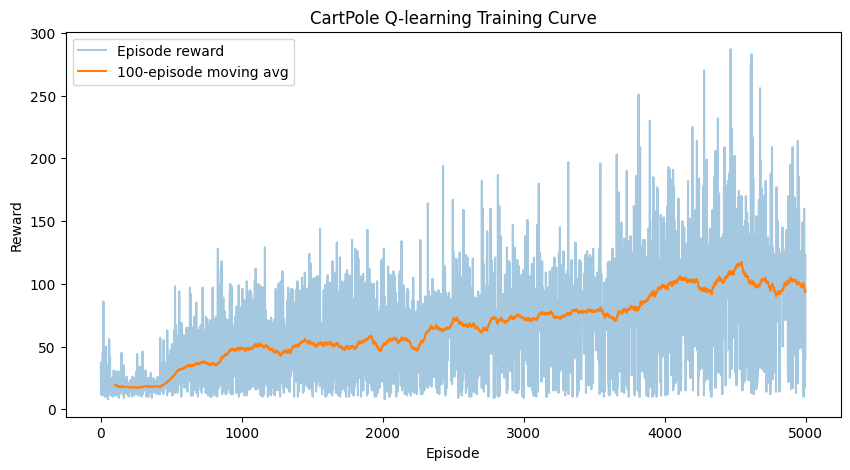

In [18]:
# Reviewing Training
import matplotlib.pyplot as plt
import numpy as np

window = 100
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode="valid")

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.4, label="Episode reward")
plt.plot(range(window - 1, len(episode_rewards)), moving_avg, label="100-episode moving avg")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("CartPole Q-learning Training Curve")
plt.legend()
plt.show()

In [19]:
# Eval 

env = gym.make("CartPole-v1", render_mode="human")

eval_rewards = []

for episode in range(20):
    obs, info = env.reset()
    state = discretize(obs)
    done = False
    total_reward = 0

    while not done:
        action = np.argmax(q_table[state])
        obs, reward, terminated, truncated, info = env.step(action)
        state = discretize(obs)
        total_reward += reward
        done = terminated or truncated

    eval_rewards.append(total_reward)
    print(f"Eval episode {episode+1}: reward = {total_reward}")

env.close()

print("Average eval reward:", np.mean(eval_rewards))

Eval episode 1: reward = 148.0
Eval episode 2: reward = 93.0
Eval episode 3: reward = 84.0
Eval episode 4: reward = 44.0
Eval episode 5: reward = 47.0
Eval episode 6: reward = 111.0
Eval episode 7: reward = 68.0
Eval episode 8: reward = 46.0
Eval episode 9: reward = 90.0
Eval episode 10: reward = 96.0
Eval episode 11: reward = 21.0
Eval episode 12: reward = 36.0
Eval episode 13: reward = 31.0
Eval episode 14: reward = 50.0
Eval episode 15: reward = 95.0
Eval episode 16: reward = 86.0
Eval episode 17: reward = 86.0
Eval episode 18: reward = 91.0
Eval episode 19: reward = 74.0
Eval episode 20: reward = 98.0
Average eval reward: 74.75


In [20]:
!pip freeze > requirements.txt